# Lab 10 - Feature selection


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

from scipy.stats import chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


## Task 1 - data generation


In [2]:
def generate_dataset(kind=1, n=500, p=50, k=10, random_state=42):
    local_rng = np.random.default_rng(random_state)
    X = local_rng.normal(size=(n, p))
    if kind == 1:
        y = (np.sum(X[:, :k] ** 2, axis=1) > chi2.ppf(0.5, df=k)).astype(int)
    elif kind == 2:
        y = (np.sum(np.abs(X[:, :k]), axis=1) > k).astype(int)
    else:
        raise ValueError("kind must be 1 or 2")
    return X, y, set(range(k))


for kind in [1, 2]:
    X, y, true_set = generate_dataset(kind=kind)
    corrs = [abs(np.corrcoef(X[:, j], y)[0, 1]) for j in range(10)]
    print("dataset", kind, "mean abs marginal corr for relevant features:", np.nanmean(corrs))


dataset 1 mean abs marginal corr for relevant features: 0.03971793848800888
dataset 2 mean abs marginal corr for relevant features: 0.052294354021457254


The relevant variables are not necessarily detectable by simple marginal correlation because the signal is nonlinear and symmetric in `X_j` through squares or absolute values.


## Task 2 - feature rankings: RF impurity, permutation, Boruta-like shadows


In [3]:
def rf_importance_rankings(X, y, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=random_state)
    rf = RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1).fit(X_train, y_train)
    mdi = rf.feature_importances_
    perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=random_state, n_jobs=-1).importances_mean
    return mdi, perm, rf


def boruta_like(X, y, random_state=42):
    local_rng = np.random.default_rng(random_state)
    X_shadow = np.column_stack([local_rng.permutation(X[:, j]) for j in range(X.shape[1])])
    X_aug = np.column_stack([X, X_shadow])
    rf = RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1).fit(X_aug, y)
    imp = rf.feature_importances_
    real_imp = imp[:X.shape[1]]
    shadow_threshold = imp[X.shape[1]:].max()
    return real_imp, set(np.flatnonzero(real_imp > shadow_threshold)), shadow_threshold


X, y, true_set = generate_dataset(kind=1, n=500, p=50, k=10, random_state=RANDOM_STATE)
mdi, perm, rf = rf_importance_rankings(X, y)
boruta_imp, boruta_selected, shadow_threshold = boruta_like(X, y)
print("MDI top 10:", sorted(np.argsort(mdi)[-10:] + 1))
print("Permutation top 10:", sorted(np.argsort(perm)[-10:] + 1))
print("Boruta-like selected:", sorted(i + 1 for i in boruta_selected))


MDI top 10: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(43)]
Permutation top 10: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10), np.int64(30), np.int64(48)]
Boruta-like selected: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [4]:
def recovery_experiment(kind=1, n=500, p=50, k=10, L=30):
    successes = {"mdi": [], "perm": [], "boruta": []}
    for rep in range(L):
        X, y, true_set = generate_dataset(kind=kind, n=n, p=p, k=k, random_state=1000 + rep)
        mdi, perm, _ = rf_importance_rankings(X, y, random_state=2000 + rep)
        _, boruta_selected, _ = boruta_like(X, y, random_state=3000 + rep)
        successes["mdi"].append(set(np.argsort(mdi)[-k:]) == true_set)
        successes["perm"].append(set(np.argsort(perm)[-k:]) == true_set)
        successes["boruta"].append(true_set.issubset(boruta_selected))
    return {name: np.mean(vals) for name, vals in successes.items()}


for kind in [1, 2]:
    print("dataset", kind, recovery_experiment(kind=kind, L=10))


dataset 1 {'mdi': np.float64(0.3), 'perm': np.float64(0.1), 'boruta': np.float64(0.7)}
dataset 2 {'mdi': np.float64(0.2), 'perm': np.float64(0.0), 'boruta': np.float64(0.6)}


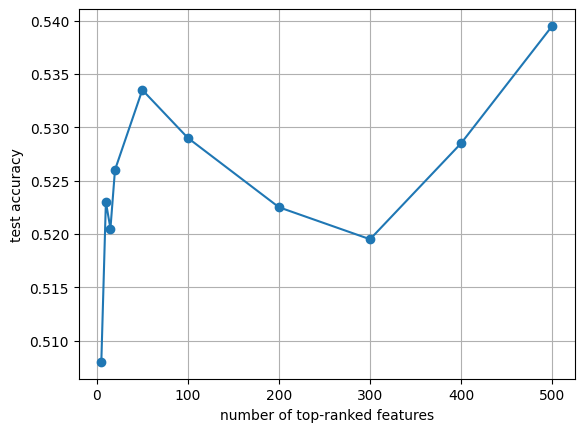

In [5]:
X_train, y_train, true_set = generate_dataset(kind=1, n=200, p=500, k=20, random_state=RANDOM_STATE)
X_test, y_test, _ = generate_dataset(kind=1, n=2000, p=500, k=20, random_state=RANDOM_STATE + 1)
rf_rank = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
ranking = np.argsort(rf_rank.feature_importances_)[::-1]
ts = [5, 10, 15, 20, 50, 100, 200, 300, 400, 500]
accs = []
for t in ts:
    chosen = ranking[:t]
    clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train[:, chosen], y_train)
    accs.append(accuracy_score(y_test, clf.predict(X_test[:, chosen])))

plt.plot(ts, accs, marker="o")
plt.xlabel("number of top-ranked features")
plt.ylabel("test accuracy")
plt.grid(True)
plt.show()


Boruta uses shadow variables as a data-driven null benchmark. Beating the best shuffled feature is more meaningful than having a positive importance, because tree importances are rarely exactly zero even for noise features.
